In [51]:
import math as mt
import torch as tc
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn

### Positional Encoding

Since the Transformer processes all tokens simultaneously, it has no inherent notion of sequence order. Sinusoidal positional encoding is added to the input embeddings to provide information about the position of each element in the sequence.

Different frequencies are used across dimensions, allowing each position to obtain a unique representation while preserving relative positional relationships.

In [52]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = tc.zeros(max_len, d_model)
        
        position = tc.arange(0,max_len,dtype=tc.float).unsqueeze(1)
        div_term = tc.exp(tc.arange(0,d_model,2).float()*(-mt.log(10000.0) / d_model))
        
        pe[:, 0::2] = tc.sin(position * div_term)
        pe[:, 1::2] = tc.cos(position * div_term)
        self.register_buffer("pe",pe.unsqueeze(0))
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

### Multi-Head Self-Attention

This cell implements the core mechanism of the Transformer. Query (Q), Key (K), and Value (V) representations are generated for each token, allowing every element in the sequence to directly interact with all other elements.

The feature space is divided into multiple attention heads, enabling the model to learn different comparison patterns simultaneously. This is particularly important for the ranking task, where determining the rank of an element requires comparing it against the entire sequence.

In [80]:
class Attention(nn.Module):

    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)

        self.fc = nn.Linear(d_model, d_model)

    def forward(self, x):
        batch_size = x.size(0)
        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)
        
        Q = Q.view(batch_size,-1,self.num_heads,self.head_dim).transpose(1, 2)
        K = K.view(batch_size,-1,self.num_heads,self.head_dim).transpose(1, 2)
        V = V.view(batch_size,-1,self.num_heads,self.head_dim).transpose(1, 2)
        
        scores = tc.matmul(Q,K.transpose(-2, -1)) / mt.sqrt(self.head_dim)

        attention = tc.softmax(scores,dim=-1)
        self.attention_weights = attention
        out = tc.matmul(attention,V)
        out = out.transpose(1,2).contiguous()
        out = out.view(batch_size,-1,self.d_model)

        return self.fc(out)

### Feed-Forward Network

After self-attention gathers information from the entire sequence, a feed-forward network is applied independently to each token. The feature dimension is expanded and then projected back, allowing the model to learn more complex representations from the contextual information produced by attention.

In [81]:
class Forward(nn.Module):

    def __init__(self, d_model, ff_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, ff_dim),nn.ReLU(),nn.Linear(ff_dim, d_model))

    def forward(self, x):
        return self.net(x)

### Transformer Encoder Block

This encoder block combines multi-head self-attention and a feed-forward network using residual connections and layer normalization. Residual connections help preserve useful information from previous layers, while layer normalization improves training stability and convergence.

The encoder block serves as the fundamental building unit of the Transformer, enabling the model to progressively learn richer relational representations.

In [82]:
class Transformer(nn.Module):

    def __init__(self, d_model, num_heads, ff_dim):
        super().__init__()

        self.attn = Attention(d_model,num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = Forward(d_model,ff_dim)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out = self.attn(x)
        x = self.norm1(x + attn_out)
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)

        return x

### Transformer Ranker Architecture

The ranking model consists of a numerical embedding layer, sinusoidal positional encoding, two Transformer encoder blocks, and a final classification layer. The embedding layer converts scalar inputs into 64-dimensional feature vectors, while positional encoding preserves sequence order information.

Two encoder blocks are used to enable multiple rounds of relational reasoning, allowing each element to refine its representation based on information gathered from the entire sequence before predicting its rank.

In [83]:
class Ranker(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.d_model = 64
        self.embedding = nn.Linear(1,self.d_model)
        self.pos_encoding = PositionalEncoding(self.d_model,max_len=10)

        self.encoder1 = Transformer(d_model=64,num_heads=4,ff_dim=128)
        self.encoder2 = Transformer(d_model=64,num_heads=4,ff_dim=128)
        self.classifier = nn.Linear(64,10)

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.embedding(x)
        x = self.pos_encoding(x)
        x = self.encoder1(x)
        x = self.encoder2(x)
        x = self.classifier(x)
        return x

In [84]:
df = pd.read_csv("ranking_dataset.csv")

value_cols = [f"val_{i}" for i in range(10)]
rank_cols = [f"rank_{i}" for i in range(10)]

In [85]:
class rank_data(Dataset):
    def __init__(self, dataframe):

        self.X = tc.tensor(dataframe[value_cols].values,dtype=tc.float32)
        self.y = tc.tensor(dataframe[rank_cols].values,dtype=tc.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [86]:
train_df, temp_df = train_test_split(df,test_size=0.2,random_state=42)
val_df, test_df = train_test_split(temp_df,test_size=0.50,random_state=42)

train_data = rank_data(train_df)
val_data = rank_data(val_df)
test_data = rank_data(test_df)

In [87]:
train_loader = DataLoader(train_data,batch_size=64,shuffle=True)
val_loader = DataLoader(val_data,batch_size=64,shuffle=False)
test_loader = DataLoader(test_data,batch_size=64,shuffle=False)

In [88]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with tc.no_grad():
        for x, y in loader:
            logits = model(x)
            preds = logits.argmax(dim=-1)
            correct += (preds == y).sum().item()
            total += y.numel()
    return correct / total

In [89]:
def train_model(model, train_loader, val_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = tc.optim.Adam(model.parameters(),lr=5e-4)
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for x, y in train_loader:
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits.view(-1, 10),y.view(-1)) 
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_acc = evaluate(model, train_loader)
        val_acc = evaluate(model, val_loader)
        print(
            f"Epoch {epoch+1}: "
            f"Loss={running_loss/len(train_loader):.4f} | "
            f"Train={train_acc:.4f} | "
            f"Val={val_acc:.4f}"
        )
    return model

### Transformer Training and Evaluation

The Transformer model is trained using the same optimizer, loss function, training procedure, and evaluation metric used for the baseline models. Keeping all training settings unchanged ensures that performance differences can be attributed to the model architecture rather than the training process.

The trained model is then evaluated on the test set to compare its ranking performance against the MLP, RNN, and LSTM baselines.

In [ ]:
model = Ranker()

train_model(model,train_loader,val_loader)
transformer_test_acc = evaluate(model,test_loader)

print("Transformer Test Acc:",transformer_test_acc)

### Attention Visualization

Attention weights from the second encoder layer are visualized to analyze how the Transformer performs rank prediction. The heatmaps show how strongly each value attends to other values in the sequence, enabling investigation of pairwise comparisons, head specialization, and learned ranking behavior.

C:\Users\tilak\AppData\Local\Temp\ipykernel_26276\2794279426.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


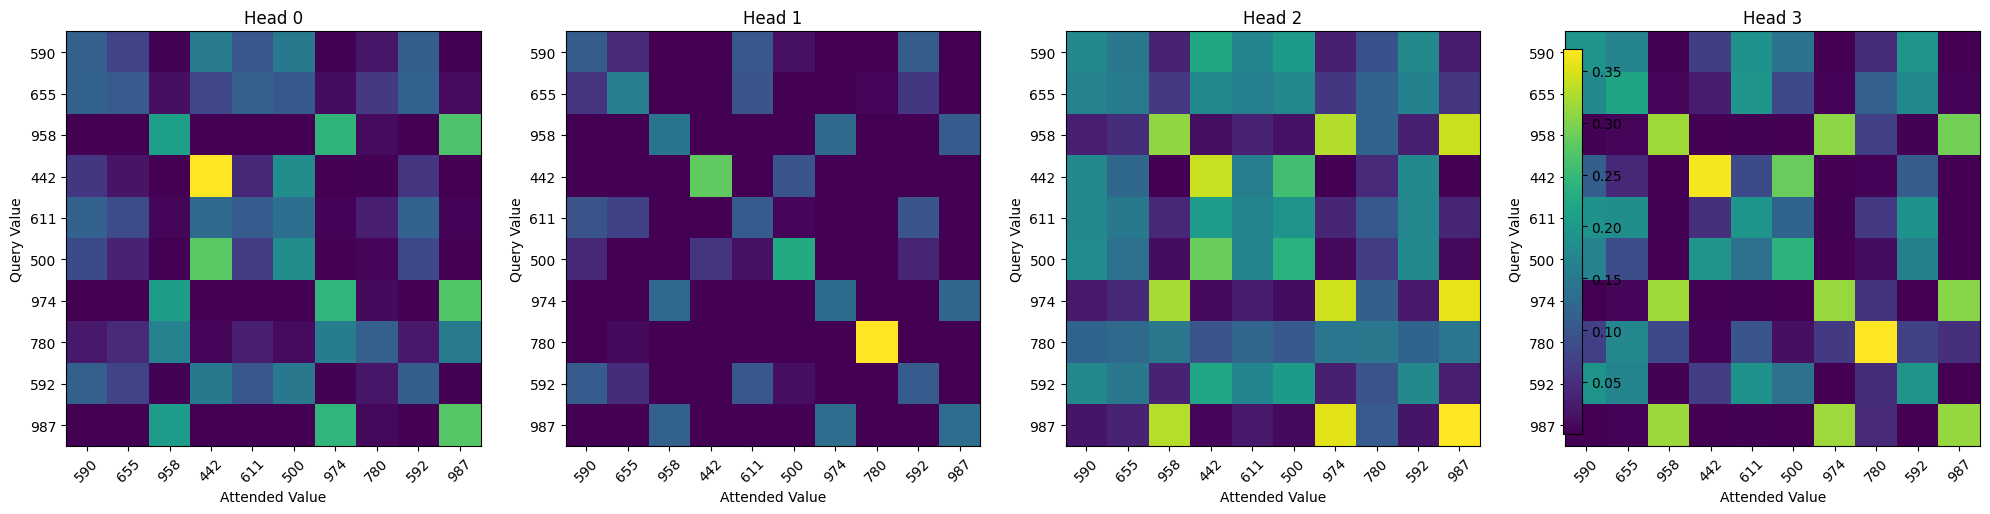

Input Sequence:
[590, 655, 958, 442, 611, 500, 974, 780, 592, 987]

Predicted Ranks:
[3, 5, 8, 0, 3, 1, 8, 6, 3, 9]


In [100]:
import matplotlib.pyplot as plt

sample_x, sample_y = next(iter(test_loader))

with tc.no_grad():
    logits = model(sample_x)
attn = model.encoder2.attn.attention_weights
values = sample_x[0].int().tolist()
preds = logits[0].argmax(dim=-1).tolist()
num_heads = attn.shape[1]
fig, axes = plt.subplots(1,num_heads,figsize=(5 * num_heads, 5))
if num_heads == 1:
    axes = [axes]
for head in range(num_heads):
    im = axes[head].imshow(attn[0, head].detach().cpu().numpy(),cmap="viridis")
    axes[head].set_title(f"Head {head}")
    axes[head].set_xticks(range(len(values)))
    axes[head].set_yticks(range(len(values)))
    axes[head].set_xticklabels(values,rotation=45)
    axes[head].set_yticklabels(values)
    axes[head].set_xlabel("Attended Value")
    axes[head].set_ylabel("Query Value")
fig.colorbar(im, ax=axes)
plt.tight_layout()
plt.show()
print("Input Sequence:")
print(values)
print("\nPredicted Ranks:")
print(preds)

_________________________________________________________________________________________________________________________________________________________
### Attention Analysis

#### 1. How does a token attend to larger or smaller numbers?

From the attention heatmaps, it can be observed that a token does not rely only on its own value while predicting its rank. Instead, it attends to multiple other values in the sequence, especially important reference values such as very large or very small numbers. This helps the model estimate where a particular value lies relative to the rest of the sequence.

#### 2. Does the model compare elements pairwise?

Yes. The attention patterns show that each value receives information from several other values rather than being processed independently. Since ranking depends on how many elements are larger or smaller than a given value, these interactions indicate that the model is performing comparisons across the sequence.

#### 3. Do different heads specialize differently?

Yes. Different attention heads exhibit different patterns. Some heads focus strongly on a few specific values, while others distribute attention across multiple values. This suggests that different heads learn different comparison strategies and capture complementary information required for ranking.

#### 4. Does a token strongly attend to important values while determining its rank?

Yes. Certain values receive noticeably higher attention than others. These values often correspond to important reference points in the sequence, such as large or small numbers. The model appears to use these reference values when estimating the rank of other elements.

#### 5. Does attention become more structured after training?

Yes. The attention maps are highly structured rather than random. Clear attention patterns emerge across different heads, indicating that meaningful relationships have been learned during training. The learned attention behavior is consistent with the strong ranking performance achieved by the Transformer model.

_________________________________________________________________________________________________________________________________________________________
### Out-of-Distribution Testing

To evaluate the generalization capability of the Transformer, the model is tested on sequences that differ significantly from the training distribution. These include sorted sequences, reverse-sorted sequences, large-valued inputs, identical values, and alternating high-low patterns.

The objective is to analyze robustness, identify potential failure modes, and determine whether the model has learned the ranking concept itself or merely memorized patterns from the training data.

In [103]:
ood_samples = tc.tensor([
    [1,2,3,4,5,6,7,8,9,10],
    [10,9,8,7,6,5,4,3,2,1],
    [1000,900,800,700,600,500,400,300,200,100],
    [5,5,5,5,5,5,5,5,5,5],
    [1,1000,2,999,3,998,4,997,5,996]
], dtype=tc.float32)

with tc.no_grad():
    preds = model(ood_samples).argmax(dim=-1)

for i in range(len(ood_samples)):
    print(f"\nSample {i+1}")
    print("Input :", ood_samples[i].int().tolist())
    print("Ranks :", preds[i].tolist())


Sample 1
Input : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Ranks : [0, 1, 1, 2, 6, 6, 7, 8, 8, 9]

Sample 2
Input : [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
Ranks : [9, 8, 7, 6, 6, 6, 6, 6, 1, 0]

Sample 3
Input : [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100]
Ranks : [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]

Sample 4
Input : [5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
Ranks : [9, 9, 9, 9, 9, 9, 9, 9, 9, 9]

Sample 5
Input : [1, 1000, 2, 999, 3, 998, 4, 997, 5, 996]
Ranks : [0, 7, 0, 7, 0, 7, 2, 7, 2, 7]


### Out-of-Distribution Analysis

#### 1. Robustness

The Transformer performed well on inputs containing values much larger than those seen during training. For example, on the sequence:

[1000, 900, 800, 700, 600, 500, 400, 300, 200, 100]

the model correctly predicted the ranking order. This shows that the model learned relative comparisons between values rather than memorizing specific numerical ranges.

#### 2. Failure Modes

The model struggled on perfectly sorted sequences and sequences containing identical values.

For the ascending sequence:

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

several ranks were repeated, indicating that the model was unable to produce a perfectly ordered ranking despite the simple pattern.

For the identical-value sequence:

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

all elements were assigned the same rank. Since there is no clear ordering among identical values, this behavior is reasonable.

#### 3. Generalization Capability

The model generalized well to large values and reverse-sorted sequences, showing that it learned the concept of relative ordering. However, performance decreased on highly structured patterns such as perfectly increasing sequences and alternating high-low sequences.

For example, on the sequence:

[1, 1000, 2, 999, 3, 998, 4, 997, 5, 996]

the model successfully separated small and large values but was unable to assign the exact rank to every element. This suggests that the model learned overall ordering relationships more effectively than precise ranking in unusual input patterns.

#### 4. Attention Behavior

The attention heatmaps showed that the model relies on interactions between multiple values in the sequence rather than processing each value independently. The learned attention patterns remained useful on out-of-distribution samples, especially when identifying very large and very small values.

### Conclusion

The Transformer demonstrated good generalization and relational reasoning ability beyond the training distribution. While it handled large values and reverse-sorted sequences effectively, performance decreased on highly structured and ambiguous inputs.